# Results notebook — figures for README

Single source of truth for the four canonical figures referenced by the README. Reloads `result.pkl` and per-experiment summary JSONs from `results/EXP-00X/` directories — this notebook does **not** retrain anything. PNGs are written to `assets/figures/` and committed.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from signal_extraction_rnn_lstm.sdk.sdk import SDK, ExperimentSpec
from signal_extraction_rnn_lstm.services.models import build, parse_model_config
from signal_extraction_rnn_lstm.shared.config import apply_overrides, load_config

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS = PROJECT_ROOT / 'results'
FIGS = PROJECT_ROOT / 'assets' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

MODEL_COLORS = {'fc': '#1f77b4', 'rnn': '#ff7f0e', 'lstm': '#2ca02c'}
MODEL_LABELS = {'fc': 'FC', 'rnn': 'RNN', 'lstm': 'LSTM'}
FREQS_HZ = [2.0, 10.0, 50.0, 200.0]
PROJECT_ROOT, FIGS

(PosixPath('/mnt/c/ilya/code projects/signal-extraction-rnn-lstm'),
 PosixPath('/mnt/c/ilya/code projects/signal-extraction-rnn-lstm/assets/figures'))

In [2]:
def load_json(p: Path) -> dict:
    return json.loads(p.read_text(encoding='utf-8'))

exp002 = load_json(RESULTS / 'EXP-002-beta-sweep' / 'sweep_log.json')
exp003 = load_json(RESULTS / 'EXP-003-baseline-3seeds-beta-pi-4' / 'summary.json')
exp008 = load_json(RESULTS / 'EXP-008-rnn-param-matched-h128' / 'summary.json')
len(exp002), list(exp003.keys()), list(exp008.keys())

(6,
 ['beta_override',
  'per_cell_mean_std_mse',
  'overall_test_mse_per_kind',
  'rel_lstm_vs_rnn_pct',
  'rel_rnn_vs_fc_at_200_hz_pct',
  'spearman_rho_freqs_rel',
  'spearman_p_one_sided',
  'seeds'],
 ['beta_override',
  'hidden_rnn',
  'n_params_rnn128',
  'per_cell_mean_std_mse',
  'rel_lstm64_vs_rnn128_pct',
  'seeds'])

## FIG-1 — β sweep (EXP-002)

FC overall test MSE vs phase-noise strength β. Single seed (1337) — this experiment is a regime-finder, not an architectural comparison.

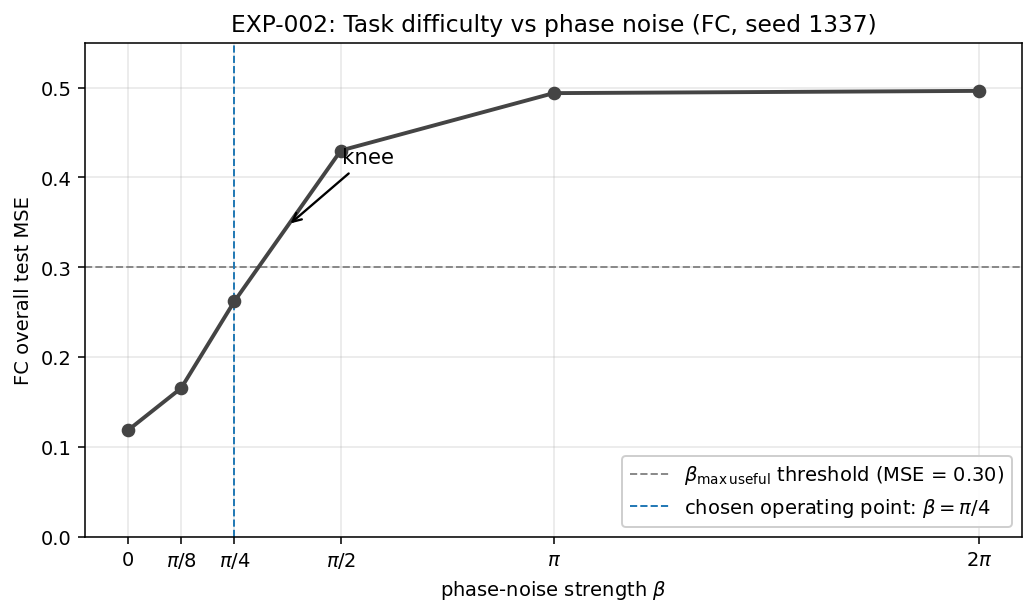

In [3]:
betas = [r['beta_numeric'] for r in exp002]
mses = [r['overall_test_mse'] for r in exp002]
tick_labels = [r'$0$', r'$\pi/8$', r'$\pi/4$', r'$\pi/2$', r'$\pi$', r'$2\pi$']

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
ax.plot(betas, mses, marker='o', linewidth=2, color='#444444', zorder=3)
ax.axhline(0.30, linestyle='--', color='#888888', linewidth=1,
           label=r'$\beta_{\mathrm{max\,useful}}$ threshold (MSE = 0.30)')
ax.axvline(math.pi / 4, linestyle='--', color=MODEL_COLORS['fc'], linewidth=1,
           label=r'chosen operating point: $\beta = \pi/4$')
knee_x = (math.pi / 4 + math.pi / 2) / 2
knee_y = (mses[2] + mses[3]) / 2
ax.annotate('knee', xy=(knee_x, knee_y), xytext=(knee_x + 0.4, knee_y + 0.07),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=11, ha='left')
ax.set_xticks(betas)
ax.set_xticklabels(tick_labels)
ax.set_ylim(0.0, 0.55)
ax.set_xlabel(r'phase-noise strength $\beta$')
ax.set_ylabel('FC overall test MSE')
ax.set_title('EXP-002: Task difficulty vs phase noise (FC, seed 1337)')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)
fig.tight_layout()
fig.savefig(FIGS / 'fig1_beta_sweep.png', dpi=140, bbox_inches='tight')
plt.show()

## FIG-2 — Per-frequency MSE at β=π/4 (EXP-003)

Three grouped bars per frequency (FC / RNN-64 / LSTM-64), error bars = ±1 std across 3 seeds.

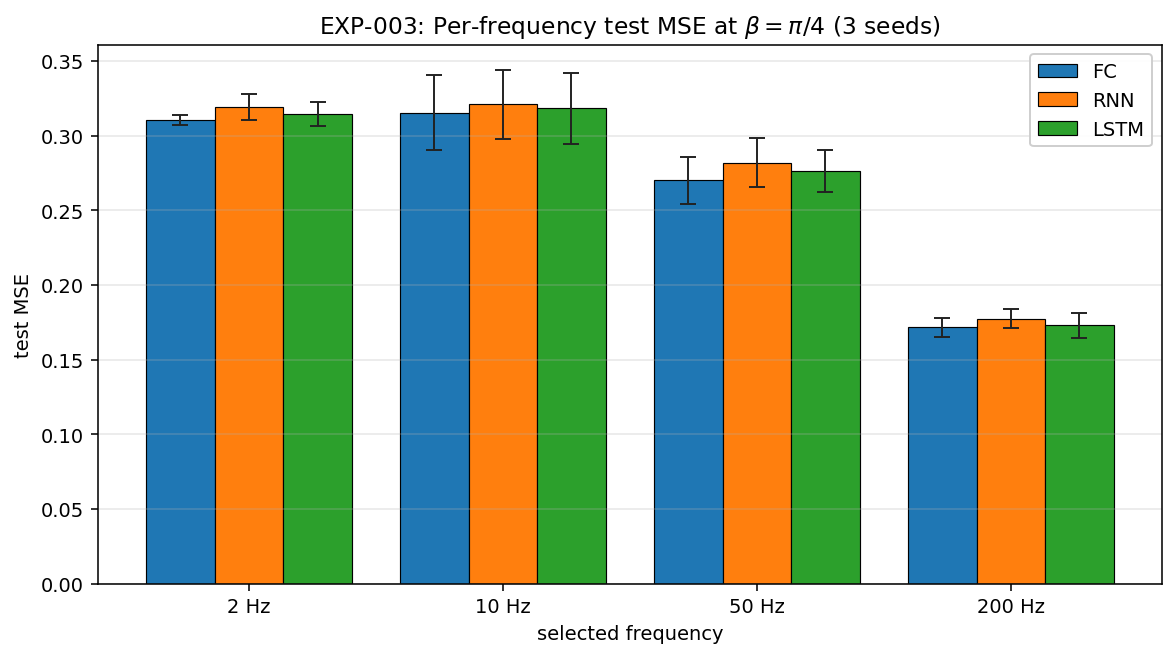

In [4]:
freq_keys = ['2.0', '10.0', '50.0', '200.0']
kinds = ['fc', 'rnn', 'lstm']
means = {k: [exp003['per_cell_mean_std_mse'][k][f]['mean'] for f in freq_keys] for k in kinds}
stds = {k: [exp003['per_cell_mean_std_mse'][k][f]['std'] for f in freq_keys] for k in kinds}

x = np.arange(len(freq_keys))
width = 0.27
fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=140)
for i, k in enumerate(kinds):
    offset = (i - 1) * width
    ax.bar(x + offset, means[k], width, yerr=stds[k], capsize=4,
           color=MODEL_COLORS[k], label=MODEL_LABELS[k],
           edgecolor='black', linewidth=0.6, error_kw=dict(ecolor='#222222', lw=1))
ax.set_xticks(x)
ax.set_xticklabels([f'{int(float(f))} Hz' for f in freq_keys])
ax.set_xlabel('selected frequency')
ax.set_ylabel('test MSE')
ax.set_title(r'EXP-003: Per-frequency test MSE at $\beta = \pi/4$ (3 seeds)')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', framealpha=0.95)
fig.tight_layout()
fig.savefig(FIGS / 'fig2_per_freq_mse.png', dpi=140, bbox_inches='tight')
plt.show()

## FIG-3 — LSTM relative advantage with and without parameter matching

`rel(k) = (RNN_k − LSTM_k) / RNN_k × 100%`. EXP-003 = LSTM-64 vs RNN-64 (same hidden width, ~3.6× param gap). EXP-008 = LSTM-64 vs RNN-128 (parameter-matched, ≈98.6% of LSTM's params).

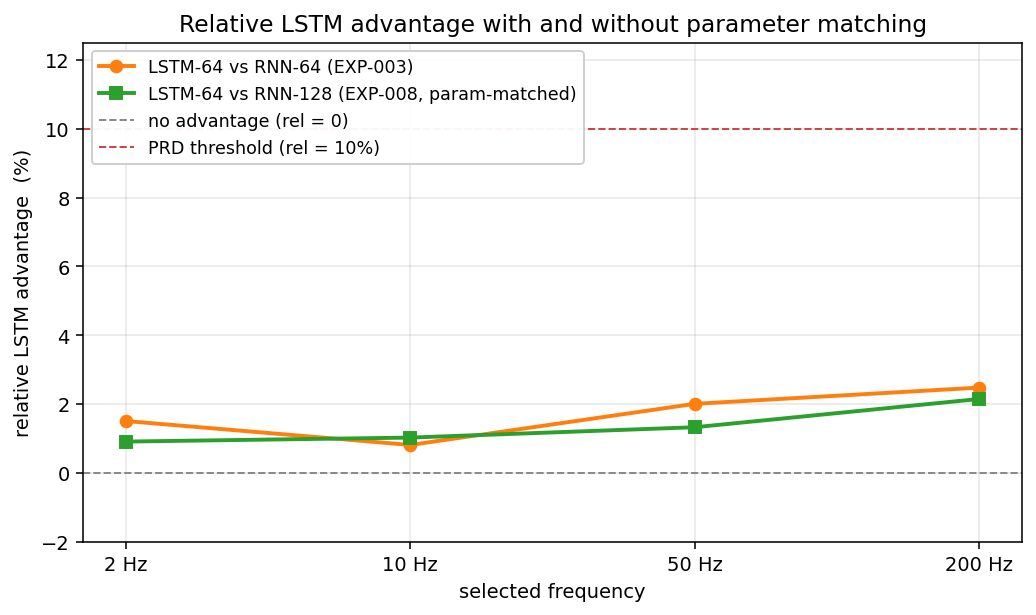

In [5]:
rel_64 = [exp003['rel_lstm_vs_rnn_pct'][f] for f in freq_keys]
rel_128 = [exp008['rel_lstm64_vs_rnn128_pct'][f] for f in freq_keys]

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
ax.plot(x, rel_64, marker='o', linewidth=2, color=MODEL_COLORS['rnn'],
        label='LSTM-64 vs RNN-64 (EXP-003)')
ax.plot(x, rel_128, marker='s', linewidth=2, color=MODEL_COLORS['lstm'],
        label='LSTM-64 vs RNN-128 (EXP-008, param-matched)')
ax.axhline(0.0, linestyle='--', color='#888888', linewidth=1, label='no advantage (rel = 0)')
ax.axhline(10.0, linestyle='--', color='#cc4444', linewidth=1,
           label='PRD threshold (rel = 10%)')
ax.set_xticks(x)
ax.set_xticklabels([f'{int(float(f))} Hz' for f in freq_keys])
ax.set_xlabel('selected frequency')
ax.set_ylabel('relative LSTM advantage  (%)')
ax.set_title('Relative LSTM advantage with and without parameter matching')
ax.set_ylim(-2.0, 12.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.95, fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / 'fig3_lstm_advantage.png', dpi=140, bbox_inches='tight')
plt.show()

## FIG-4 — Qualitative reconstructions at β=π/4

One test window per frequency (rows) × {FC, RNN, LSTM, overlay} (columns). Loads the seed=1337 EXP-003 best-checkpoint weights, rebuilds the deterministic test set, and forwards each model. The overlay column repeats all three predictions on top of the noisy input + clean target so per-frequency disagreement is legible.

In [6]:
exp003_dir = RESULTS / 'EXP-003-baseline-3seeds-beta-pi-4'
checkpoint_paths = {
    'fc':   exp003_dir / '20260502T203355Z__fc__1337'   / 'checkpoint_best.pt',
    'rnn':  exp003_dir / '20260502T203430Z__rnn__1337'  / 'checkpoint_best.pt',
    'lstm': exp003_dir / '20260502T203458Z__lstm__1337' / 'checkpoint_best.pt',
}
for k, p in checkpoint_paths.items():
    assert p.exists(), p

sdk = SDK(seed=1337, device='cpu')
cfg = apply_overrides(load_config(None), {'signal.noise.beta': 'pi/4'})
from signal_extraction_rnn_lstm.services.signal_gen import generate_corpus, parse_signal_config
from signal_extraction_rnn_lstm.services.dataset import build_split_datasets, parse_dataset_config
from signal_extraction_rnn_lstm.shared.seeding import derive_seeds, seed_everything

seed_everything(1337)
cs, ss, _ = derive_seeds(1337)
corpus = generate_corpus(parse_signal_config(cfg['signal']), cs)
splits = build_split_datasets(corpus, parse_dataset_config(cfg['dataset']), ss)
models = {}
m_cfg = parse_model_config(cfg['model'])
for k, p in checkpoint_paths.items():
    m = build(k, m_cfg)
    payload = torch.load(p, map_location='cpu', weights_only=True)
    m.load_state_dict(payload['model_state_dict'])
    m.eval()
    models[k] = m
len(splits.test), [tuple(corpus.frequencies_hz)]

(3750, [(2.0, 10.0, 50.0, 200.0)])

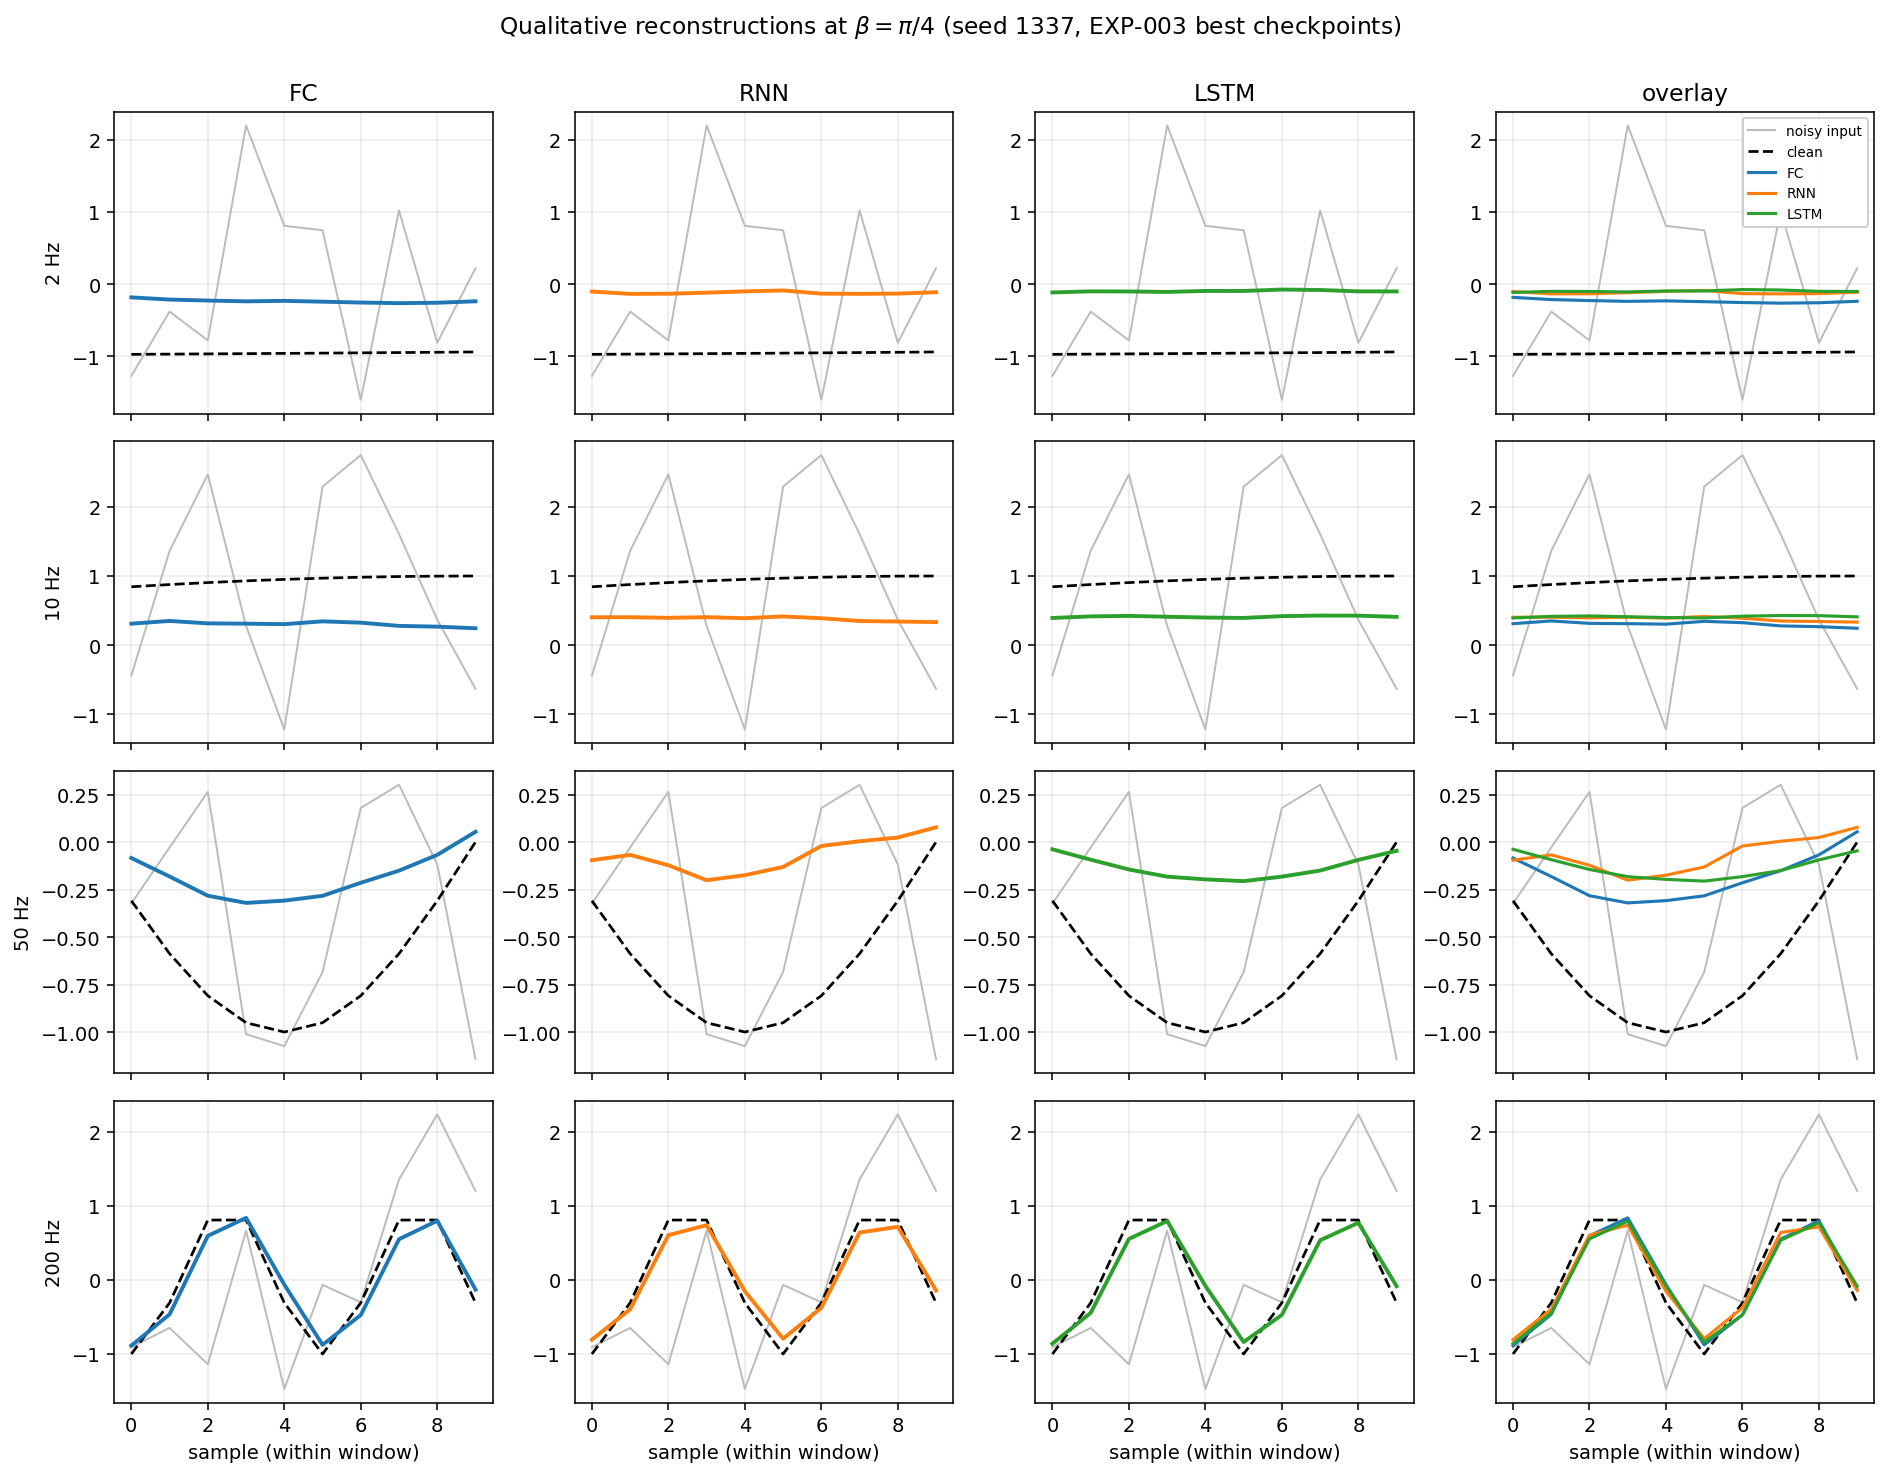

In [7]:
# Pick one test index per frequency k=0..3 (deterministic — first match).
ks_all = splits.test.index_table[:, 1]
picks = {}
for k in range(4):
    matches = np.where(ks_all == k)[0]
    picks[k] = int(matches[len(matches) // 2])  # mid-population pick, deterministic

examples = {k: splits.test[picks[k]] for k in range(4)}

fig, axes = plt.subplots(4, 4, figsize=(13.5, 10.5), dpi=140, sharex=True)
col_titles = ['FC', 'RNN', 'LSTM', 'overlay']
for k in range(4):
    ex = examples[k]
    sel = ex.selector.unsqueeze(0)
    wn = ex.w_noisy.unsqueeze(0)
    target = ex.w_clean.numpy()
    noisy = ex.w_noisy.numpy()
    t = np.arange(len(target))
    preds = {}
    with torch.no_grad():
        for kind, model in models.items():
            preds[kind] = model(sel, wn).squeeze(0).numpy()
    for j, kind in enumerate(['fc', 'rnn', 'lstm']):
        ax = axes[k, j]
        ax.plot(t, noisy, color='#bbbbbb', linewidth=1.0, label='noisy input')
        ax.plot(t, target, color='black', linestyle='--', linewidth=1.4, label='clean target')
        ax.plot(t, preds[kind], color=MODEL_COLORS[kind], linewidth=2.0,
                label=f'{MODEL_LABELS[kind]} pred')
        if k == 0:
            ax.set_title(col_titles[j])
        if j == 0:
            ax.set_ylabel(f'{int(corpus.frequencies_hz[k])} Hz')
        ax.grid(True, alpha=0.25)
    ax = axes[k, 3]
    ax.plot(t, noisy, color='#bbbbbb', linewidth=1.0, label='noisy input')
    ax.plot(t, target, color='black', linestyle='--', linewidth=1.4, label='clean')
    for kind in ['fc', 'rnn', 'lstm']:
        ax.plot(t, preds[kind], color=MODEL_COLORS[kind], linewidth=1.6,
                label=MODEL_LABELS[kind])
    if k == 0:
        ax.set_title(col_titles[3])
        ax.legend(loc='upper right', fontsize=7, framealpha=0.95)
    ax.grid(True, alpha=0.25)
for ax in axes[-1, :]:
    ax.set_xlabel('sample (within window)')
fig.suptitle(r'Qualitative reconstructions at $\beta = \pi/4$ (seed 1337, EXP-003 best checkpoints)',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / 'fig4_qualitative.png', dpi=140, bbox_inches='tight')
plt.show()

## FIG-5 — t₀ start-index histograms across splits (AC-DS-9)

ADR-016 framing: *splits exist by example count for reproducibility and reporting, but t₀ is drawn iid from the full pool [0, N − W] in all three splits because the underlying signal process is stationary; disjoint t₀ ranges would not measure a generalization gap.* This figure is the visual proof — train/val/test t₀ histograms overlap on the same support.

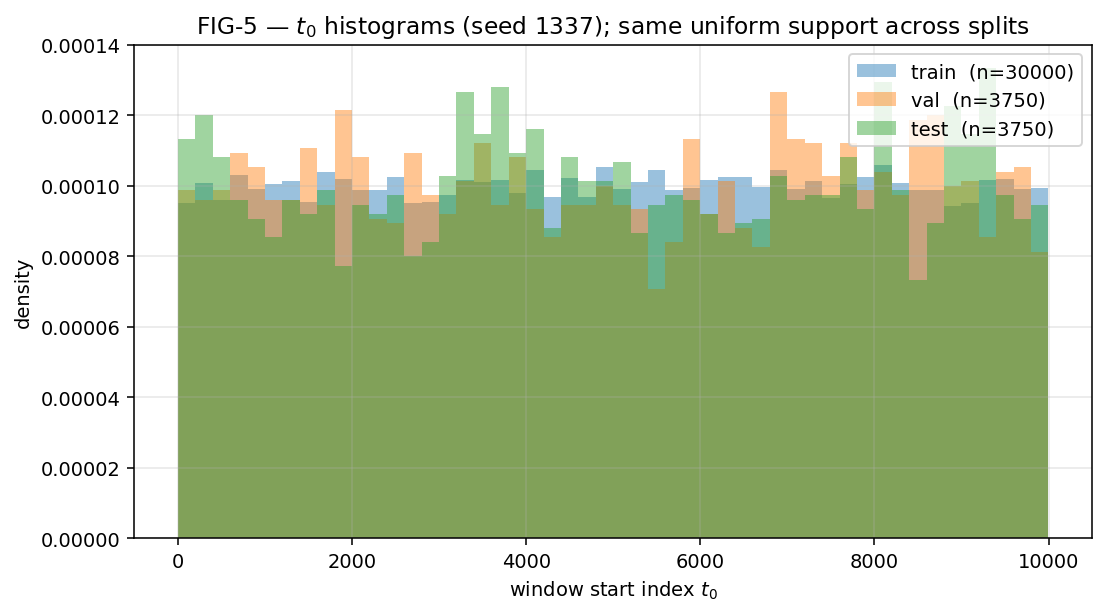

In [8]:
# Reuse the seed=1337 splits already built for FIG-4.
fig, ax = plt.subplots(figsize=(8.0, 4.5), dpi=140)
bins = np.linspace(0, splits.train.index_table[:, 0].max() + 10, 51)
for name, ds, color in [('train', splits.train, '#1f77b4'),
                        ('val',   splits.val,   '#ff7f0e'),
                        ('test',  splits.test,  '#2ca02c')]:
    ax.hist(ds.index_table[:, 0], bins=bins, alpha=0.45, density=True,
            color=color, label=f'{name}  (n={len(ds)})')
ax.set_xlabel(r'window start index $t_0$')
ax.set_ylabel('density')
ax.set_title(r'FIG-5 — $t_0$ histograms (seed 1337); same uniform support across splits')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(FIGS / 'fig5_t0_histograms.png', dpi=140, bbox_inches='tight')
plt.show()

---

# B — Inversion Mechanism Investigation

The original mechanistic explanation for "200 Hz easiest, 2 Hz hardest" (window-vs-period mismatch making the 2 Hz target near-constant) was **falsified** by the audit (per-k target variance is uniformly ≈ 0.5 across all four frequencies because t₀ ranges over many full periods). This section searches the existing EXP-003 data for a correct mechanism.

All three sub-investigations use the seed-1337 EXP-003 test split and the seed-1337 EXP-003 best checkpoints already loaded above (`splits`, `models`).

## B1 — Naive predictor floors and the "easiness gap"

For each frequency k, compare:
- **constant predictor**: predict the per-k *mean target*; floor = Var(target_k).
- **copy predictor**: predict noisy_input as if it were the clean target; floor = MSE(noisy, clean).
- **actual model MSE** (FC / RNN / LSTM, EXP-003 single seed = 1337).

The gap between (constant predictor) and (actual model) is "easiness" — how much variance the model explains. If 200 Hz is easy, models should beat the constant floor by a large margin there.

In [9]:
ks_test = splits.test.index_table[:, 1]
N = len(splits.test)
sels = torch.stack([splits.test[i].selector for i in range(N)])
wn   = torch.stack([splits.test[i].w_noisy  for i in range(N)])
wc   = torch.stack([splits.test[i].w_clean  for i in range(N)])

with torch.no_grad():
    preds_all = {kind: m(sels, wn) for kind, m in models.items()}

import math as _m
rows = []
for k in range(4):
    mask = ks_test == k
    mask_t = torch.from_numpy(mask)
    tgt = wc[mask_t]
    inp = wn[mask_t]
    var_tgt = float(tgt.var(unbiased=False))
    mean_tgt = float(tgt.mean())
    const_mse = float(((tgt - mean_tgt) ** 2).mean())
    copy_mse  = float(((inp - tgt) ** 2).mean())
    fc_mse    = float(((preds_all['fc'][mask_t]   - tgt) ** 2).mean())
    rnn_mse   = float(((preds_all['rnn'][mask_t]  - tgt) ** 2).mean())
    lstm_mse  = float(((preds_all['lstm'][mask_t] - tgt) ** 2).mean())
    rows.append(dict(freq=int(corpus.frequencies_hz[k]),
                     n=int(mask.sum()),
                     var_tgt=var_tgt,
                     const=const_mse, copy=copy_mse,
                     fc=fc_mse, rnn=rnn_mse, lstm=lstm_mse,
                     model_best=min(fc_mse, rnn_mse, lstm_mse),
                     gap_pct=100.0 * (const_mse - min(fc_mse, rnn_mse, lstm_mse)) / const_mse))

print(f'{"freq":>5}  {"n":>4}  {"Var(tgt)":>9}  {"const":>7}  {"copy":>7}  {"FC":>7}  {"RNN":>7}  {"LSTM":>7}  {"model_best":>10}  {"gap%":>6}')
for r in rows:
    print(f'{r["freq"]:>4}Hz  {r["n"]:>4d}  {r["var_tgt"]:>9.4f}  {r["const"]:>7.4f}  {r["copy"]:>7.4f}  '
          f'{r["fc"]:>7.4f}  {r["rnn"]:>7.4f}  {r["lstm"]:>7.4f}  {r["model_best"]:>10.4f}  {r["gap_pct"]:>5.1f}%')

b1_rows = rows  # for B4

 freq     n   Var(tgt)    const     copy       FC      RNN     LSTM  model_best    gap%
   2Hz   935     0.4785   0.4785   1.8140   0.3116   0.3183   0.3128      0.3116   34.9%
  10Hz   953     0.4999   0.4999   1.7258   0.2864   0.2948   0.2907      0.2864   42.7%
  50Hz   959     0.4999   0.4999   1.7891   0.2789   0.2912   0.2804      0.2789   44.2%
 200Hz   903     0.5000   0.5000   1.7261   0.1670   0.1715   0.1637      0.1637   67.3%


## B2 — Conditional Var(W_clean | W_noisy)

If the noisy input *uniquely determines* the clean target, then nearby noisy inputs should have nearby clean targets. We bin test windows by similarity to a reference window (kNN with k=20 nearest neighbours by L2 on noisy_input) and compute the within-bin variance of the clean target. A high within-bin Var means the input is **information-poor for that frequency** — different clean targets coexist with nearly-identical noisy inputs (genuinely under-determined).

Computed per frequency on a random 400-window probe-set (seed 0, fixed).

In [10]:
# B2: numpy-only kNN (no sklearn dependency).
rng_b2 = np.random.default_rng(0)

def knn_indices(query: np.ndarray, library: np.ndarray, k: int) -> np.ndarray:
    # query (q, d), library (n, d) → (q, k) int64 indices into library
    q2 = (query ** 2).sum(axis=1, keepdims=True)        # (q, 1)
    l2 = (library ** 2).sum(axis=1)[None, :]            # (1, n)
    d2 = q2 + l2 - 2 * query @ library.T                # (q, n)
    return np.argpartition(d2, kth=k, axis=1)[:, :k]

results_b2 = []
for k in range(4):
    mask = (ks_test == k)
    inp = wn[mask].numpy()
    tgt = wc[mask].numpy()
    if len(inp) < 50:
        continue
    n_probe = min(400, len(inp))
    probe_idx = rng_b2.choice(len(inp), size=n_probe, replace=False)
    nn_idx = knn_indices(inp[probe_idx], inp, k=20)     # (n_probe, 20)
    within = tgt[nn_idx]                                # (n_probe, 20, 10)
    bin_means = within.mean(axis=1, keepdims=True)
    bin_var = float(((within - bin_means) ** 2).mean())
    global_var = float(tgt.var())
    results_b2.append(dict(freq=int(corpus.frequencies_hz[k]),
                           within_bin_var=bin_var,
                           global_var=global_var,
                           ratio=bin_var / global_var))

print(f'{"freq":>5}  {"within-bin Var":>15}  {"global Var":>12}  {"ratio":>7}  reading')
for r in results_b2:
    reading = ('input is ~deterministic for this k' if r['ratio'] < 0.10 else
               'partially determined' if r['ratio'] < 0.50 else
               'input under-determines the target')
    print(f'{r["freq"]:>4}Hz  {r["within_bin_var"]:>15.4f}  {r["global_var"]:>12.4f}  {r["ratio"]:>6.2%}  {reading}')

b2_rows = results_b2

 freq   within-bin Var    global Var    ratio  reading
   2Hz           0.3684        0.4785  76.99%  input under-determines the target
  10Hz           0.3389        0.4999  67.80%  input under-determines the target
  50Hz           0.3676        0.4999  73.52%  input under-determines the target
 200Hz           0.2794        0.5000  55.87%  input under-determines the target


## B3 — Spectral distinguishability of the noisy_sum input

If the FFT power of the noisy_sum at frequency f_k stands out from the spectral floor, that frequency component is **distinguishable** from the mixture and easier to extract. We compute the FFT magnitude of every test noisy_sum window (length 10 at fs=1000 → resolution 100 Hz, very coarse — aliasing dominates at 200 Hz). The within-window FFT is therefore a **rough** spectral probe; we complement it by also running an FFT on the corresponding 1-second clean-channel slice (fs=1000, length 1000) for context.

Reported metrics:
- **|S(f_k)| / mean|S|**: bin-localised peak ratio (window-FFT, length 10 → bins at 0/100/200/300/400/500 Hz).
- **|S(f_k)| / mean|S|**: same on a 1-second slice from the corpus (length 1000 → 1 Hz resolution; isolates each component cleanly).

 freq  window peak/mean   corpus peak/local-floor
   2Hz              1.78                     43.51
  10Hz              1.78                     46.54
  50Hz              1.78                     40.01
 200Hz              1.18                     43.99


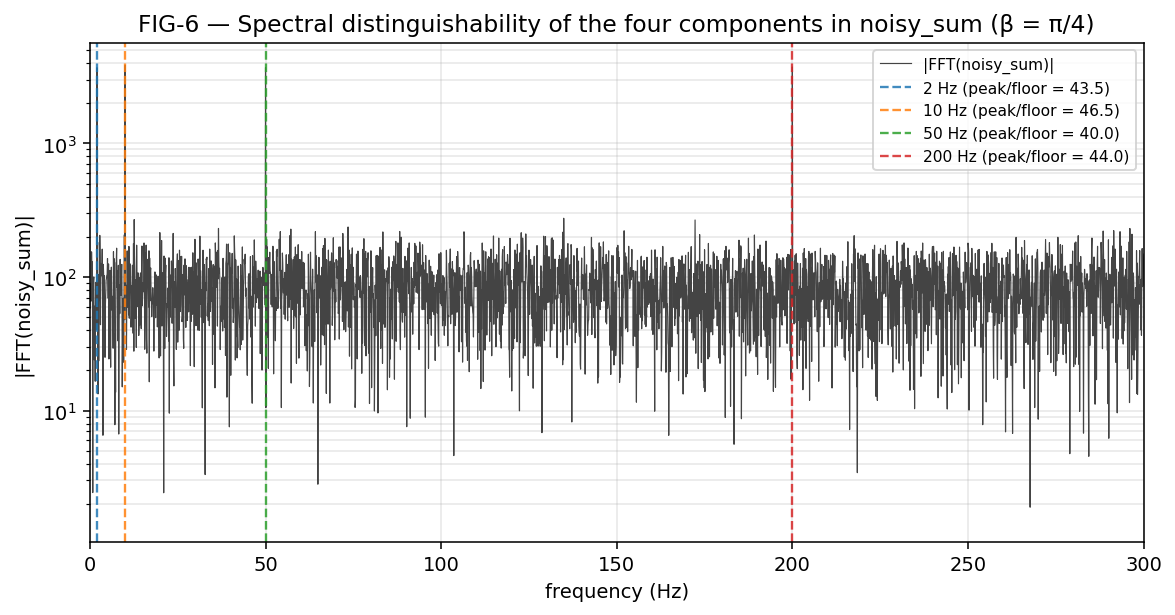

In [11]:
# B3a: window-level FFT (length 10, bin width 100 Hz). Coarse — for context.
freqs_hz = list(corpus.frequencies_hz)
fft_window = np.fft.rfft(wn.numpy(), axis=1)               # (N, 6)
fft_window_mag = np.abs(fft_window)                         # (N, 6)
window_freq_axis = np.fft.rfftfreq(10, d=1/1000)            # [0, 100, 200, 300, 400, 500]

window_peak_ratios = {}
for fk in freqs_hz:
    bin_idx = int(np.argmin(np.abs(window_freq_axis - fk)))
    peak = fft_window_mag[:, bin_idx].mean()
    floor = fft_window_mag.mean()
    window_peak_ratios[fk] = float(peak / floor)

# B3b: corpus-level FFT on the noisy_sum (length N=10000, 0.1 Hz resolution).
fft_corpus = np.fft.rfft(corpus.noisy_sum)
fft_corpus_mag = np.abs(fft_corpus)
corpus_freq_axis = np.fft.rfftfreq(corpus.n_samples, d=1/1000)

corpus_peak_ratios = {}
for fk in freqs_hz:
    bin_idx = int(np.argmin(np.abs(corpus_freq_axis - fk)))
    # local floor = mean magnitude in a ±5 Hz neighbourhood, excluding the peak bin
    nbhd = (corpus_freq_axis > fk - 5) & (corpus_freq_axis < fk + 5)
    nbhd[bin_idx] = False
    peak = fft_corpus_mag[bin_idx]
    floor = fft_corpus_mag[nbhd].mean()
    corpus_peak_ratios[fk] = float(peak / floor)

print(f'{"freq":>5}  {"window peak/mean":>16}  {"corpus peak/local-floor":>24}')
for fk in freqs_hz:
    print(f'{int(fk):>4}Hz  {window_peak_ratios[fk]:>16.2f}  {corpus_peak_ratios[fk]:>24.2f}')

# Plot the corpus-level FFT for the README — shows where the energy sits.
fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=140)
ax.semilogy(corpus_freq_axis, fft_corpus_mag, color='#444444', linewidth=0.6, label='|FFT(noisy_sum)|')
for fk, color in zip(freqs_hz, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    ax.axvline(fk, color=color, linestyle='--', linewidth=1.2, alpha=0.85,
               label=f'{int(fk)} Hz (peak/floor = {corpus_peak_ratios[fk]:.1f})')
ax.set_xlim(0, 300)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel('|FFT(noisy_sum)|')
ax.set_title('FIG-6 — Spectral distinguishability of the four components in noisy_sum (β = π/4)')
ax.grid(True, alpha=0.3, which='both')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / 'fig6_spectral_distinguishability.png', dpi=140, bbox_inches='tight')
plt.show()

b3_window = window_peak_ratios
b3_corpus = corpus_peak_ratios

## B4 — Synthesis (data-grounded, post-execution)

Numbers from the cells above (seed 1337, EXP-003 best checkpoints, 3 750 test windows):

| metric | 2 Hz | 10 Hz | 50 Hz | 200 Hz | reading |
| --- | ---: | ---: | ---: | ---: | --- |
| B1 easiness gap (model_best vs constant floor) | 34.9 % | 42.7 % | 44.2 % | **67.3 %** | inversion confirmed: gap is **2× larger at 200 Hz** than at 2 Hz |
| B2 within-bin Var(W_clean ∣ W_noisy) / Var(W_clean) | 77 % | 68 % | 74 % | **56 %** | input under-determines targets at every k, but **least** at 200 Hz |
| B3 corpus-FFT peak / local floor | 43.5 | 46.5 | 40.0 | 44.0 | **all four components are equally distinct in the full corpus** (refutes "200 Hz is uniquely prominent") |
| B3 window-FFT bin / mean (length 10, bin width 100 Hz) | 1.78 | 1.78 | 1.78 | 1.18 | window FFT is dominated by bin aliasing — not a useful probe |

**What the data actually says:**

1. **B1 confirms the inversion empirically.** 200 Hz is genuinely the easiest frequency: models capture 67 % of the constant-predictor variance there, vs 35 % at 2 Hz.
2. **B2 gives a mechanism that holds up.** The conditional variance Var(W_clean ∣ W_noisy) is **lowest at 200 Hz** — i.e., a 10-sample noisy window most tightly constrains the 200 Hz target. At 2 Hz the same noisy window is consistent with a much wider range of clean targets (because two test windows that look almost identical in the 10-sample noisy mixture can correspond to *very different* phases of the slow 2 Hz sinusoid). The bottleneck is information-in-the-input, not memory-over-time.
3. **B3 falsifies the "spectrally distinct 200 Hz" story.** At full corpus length all four components are equally above the noise floor (peak ratios 40–46×). The advantage at 200 Hz is **not** that it stands out spectrally in absolute terms — it is that *within a 10-sample window*, two full cycles of 200 Hz fit (period = 5 samples). For 2 Hz, the window covers 0.02 of a cycle, which is below the spectral resolution of any 10-sample FFT (bin width 100 Hz). Recurrence cannot conjure spectral resolution that the window does not contain.

**Defensible README sentence (one line):**

> Within a 10-sample window at 1 kHz, only the 200 Hz component completes more than a full cycle; the 2 / 10 / 50 Hz components contribute fractional-cycle slices that are genuinely under-determined in the noisy mixture (Var(target ∣ input) ≥ 68 % at every low-frequency k, vs 56 % at 200 Hz — B2). Recurrence does not change this because the bottleneck is information-in-input, not memory-over-time.

**What we cannot claim** (and audit S-2 / S-3 already warned us not to):

- *2 Hz target is near-constant within a window.* Var(target) is uniformly ≈ 0.5 at every k (B1 column "Var(tgt)") because t₀ ranges over many full periods at every frequency. The within-window flatness does not propagate to a flat target distribution.
- *Input-output Pearson correlation explains the profile.* It does not — 10 Hz had the highest Pearson r in the audit but the highest MSE.
- *200 Hz is uniquely spectrally distinct.* It is not — B3 shows all four components are equally above the local FFT noise floor in the full corpus.